#  E-commerce User Behavior Prediction with LSTM

### Group Members

| Name              | PRN            |
|------------------|----------------|
| Yogeshwar Kadam  | 202301040071   |
| Devesh Kumar     | 202301040241   |
| Abhishek Patil   | 202301040232   |


### Project : User Behavior Sequence Prediction for E-commerce

#### Discussion:

**Core Concept:**
This project aims to develop an LSTM (Long Short-Term Memory) model to predict the next action a user is likely to take on an e-commerce website. By analyzing sequences of past user interactions (e.g., viewing a product, adding to cart, searching, purchasing), the model will learn patterns and predict the subsequent behavior. This can be invaluable for personalized recommendations, dynamic content adjustments, and proactive engagement strategies.

**Potential Data Sources:**
1.  **User Interaction Logs:** This is the primary data source, capturing every click, view, search, add-to-cart, purchase, and other events with timestamps and user IDs. Each event should also include relevant item IDs and possibly other item attributes.
2.  **Product Catalog Data:** Information about products (categories, brands, prices, descriptions, images) can enrich the user's interaction data.
3.  **User Profile Data:** Demographic information, purchase history, and preference settings (if available and anonymized) can provide additional context.

**High-Level Steps for Building the Model:**
1.  **Data Collection and Preprocessing:** Extract user interaction logs, clean the data (handle missing values, anomalies), and anonymize user IDs. Create sequences of user actions, defining a 'session' or a fixed-length window for prediction.
2.  **Feature Engineering:** Convert categorical actions and product IDs into numerical representations (e.g., using embedding layers for actions and items). Consider features like time spent on a page, frequency of certain actions, or session duration.
3.  **Sequence Creation:** For each user, generate sequences of past actions and a corresponding target (the next action). For example, if a user's sequence is A -> B -> C, the model would learn to predict C given A -> B.
4.  **Model Architecture Design:** Implement an LSTM-based neural network. The input would be a sequence of embedded user actions, and the output would be a probability distribution over all possible next actions.
5.  **Model Training:** Train the LSTM model on the prepared sequences, using appropriate loss functions (e.g., categorical cross-entropy) and optimizers.
6.  **Model Evaluation:** Assess the model's performance using metrics like accuracy, precision, recall, F1-score, and perplexity (for sequence prediction). Evaluate how well it predicts the actual next action.

**Potential Deployment Aspects:**
1.  **Real-time Prediction API:** Deploy the trained model as a RESTful API service. When a user performs an action, the API receives the current user's session history and returns the predicted next action.
2.  **Integration with E-commerce Platform:** Integrate the prediction API with the e-commerce website's frontend or backend systems to power features like:
    *   **Next-best-action recommendations:** Suggesting the next product to view or add to cart.
    *   **Personalized notifications:** Triggering emails or push notifications based on predicted churn or purchase intent.
    *   **Dynamic UI adjustments:** Changing website layout or displaying relevant information based on predicted user needs.
3.  **Scalability:** Ensure the deployed solution can handle high traffic and process predictions with low latency.
4.  **Monitoring:** Continuously monitor model performance and data drift to ensure accuracy over time.

**Evaluation of Pros and Cons:**

**Pros:**
*   **Enhanced User Experience:** Provides highly personalized and relevant interactions, leading to increased user satisfaction.
*   **Increased Conversion Rates:** By predicting and facilitating desired user actions, the model can drive sales and conversions.
*   **Improved Engagement:** Proactive recommendations and content can keep users engaged on the platform.
*   **Valuable Business Insights:** Understanding user behavior sequences can reveal deeper insights into customer journeys and pain points.
*   **Applicable to Various Industries:** The concept of sequence prediction extends beyond e-commerce to areas like healthcare, education, and finance.

**Cons:**
*   **Data Intensive:** Requires a large volume of high-quality, sequential user interaction data, which might be complex to collect and store.
*   **Computational Cost:** Training and deploying LSTM models can be computationally expensive, especially with long sequences and large vocabularies of actions/items.
*   **Cold Start Problem:** New users or new products will have limited or no historical data, making predictions challenging initially.
*   **Interpretability:** LSTM models are often considered 'black boxes', making it difficult to understand *why* a particular prediction was made.
*   **Dynamic Nature of User Behavior:** User preferences and trends can change rapidly, requiring continuous model retraining and adaptation.
*   **Ethical Considerations:** Privacy concerns related to tracking and predicting user behavior, requiring careful anonymization and adherence to data protection regulations.

 User Behavior Sequence Prediction for E-commerce

## Explanation of the LSTM Mathematical Model

Long Short-Term Memory (LSTM) networks are a special kind of Recurrent Neural Network (RNN) designed to overcome the vanishing gradient problem, which prevents traditional RNNs from learning long-term dependencies in sequential data. LSTMs achieve this through a sophisticated architecture that includes 'gates' which regulate the flow of information.

### Core Components of an LSTM Cell

Each LSTM cell (or memory block) contains three main gates and a cell state:

1.  **Forget Gate (`f_t`)**
    *   **Purpose**: Decides what information to discard from the cell state. It looks at the previous hidden state (`h_{t-1}`) and the current input (`x_t`) and outputs a number between 0 and 1 for each number in the cell state `C_{t-1}`. A value of 0 means "forget this completely," while a value of 1 means "keep this completely."
    *   **Mathematical Model**: `f_t = σ(W_f * [h_{t-1}, x_t] + b_f)`
        *   `σ`: Sigmoid activation function, which squashes values between 0 and 1.
        *   `W_f`: Weight matrix for the forget gate.
        *   `[h_{t-1}, x_t]`: Concatenation of the previous hidden state and current input.
        *   `b_f`: Bias vector for the forget gate.

2.  **Input Gate (`i_t`) and Candidate Cell State (`C'_t`)**
    *   **Purpose**: Decides what new information to store in the cell state. This involves two parts:
        *   **Input Gate (`i_t`)**: A sigmoid layer that decides which values will be updated (0 to 1 scale).
        *   **Candidate Cell State (`C'_t`)**: A `tanh` layer that creates a vector of new candidate values that could be added to the cell state.
    *   **Mathematical Model**:
        *   `i_t = σ(W_i * [h_{t-1}, x_t] + b_i)`
        *   `C'_t = tanh(W_c * [h_{t-1}, x_t] + b_c)`

3.  **Cell State (`C_t`)**
    *   **Purpose**: This is the "memory" of the LSTM. It runs straight through the entire chain of cells, allowing information to be carried forward relatively unchanged. It's updated based on the forget gate and input gate outputs.
    *   **Mathematical Model**: `C_t = f_t * C_{t-1} + i_t * C'_t`
        *   `f_t * C_{t-1}`: Element-wise multiplication, forgetting irrelevant information from the old cell state.
        *   `i_t * C'_t`: Element-wise multiplication, adding new relevant information from the candidate cell state.

4.  **Output Gate (`o_t`) and Hidden State (`h_t`)**
    *   **Purpose**: Decides what parts of the cell state will be outputted to the next hidden state. The output is based on a filtered version of the cell state.
    *   **Mathematical Model**:
        *   `o_t = σ(W_o * [h_{t-1}, x_t] + b_o)`
        *   `h_t = o_t * tanh(C_t)`
        *   `h_t`: The current hidden state, which is also passed to the next time step.

### Diagrammatic Representation (Conceptual)

```mermaid
graph LR
    subgraph LSTM Cell
        X_t[Input x_t] --> ForgetGate(Forget Gate)
        H_prev[Hidden State h_t-1] --> ForgetGate
        C_prev[Cell State C_t-1] --> ForgetGate

        ForgetGate -- f_t (0-1) --> MulF((x))
        C_prev --> MulF
        MulF -- What to forget --> AddC((+))

        X_t --> InputGate(Input Gate)
        H_prev --> InputGate
        InputGate -- i_t (0-1) --> MulI((x))

        X_t --> TanhCandidate(tanh Layer)
        H_prev --> TanhCandidate
        TanhCandidate -- C'_t (candidate) --> MulI
        MulI -- What to add --> AddC

        AddC -- New C_t --> C_curr[Cell State C_t]

        X_t --> OutputGate(Output Gate)
        H_prev --> OutputGate
        C_curr --> TanhOutput(tanh)
        OutputGate -- o_t (0-1) --> MulO((x))
        TanhOutput --> MulO
        MulO -- h_t --> H_curr[Hidden State h_t]
    end
```

### Significance for Sequence Learning

1.  **Long-Term Dependency Learning**: The primary advantage of LSTMs. The cell state acts as a conveyor belt of information, allowing data to flow through many time steps without degradation or vanishing. The gates allow the LSTM to selectively add or remove information from this cell state, effectively remembering or forgetting information over long periods.

2.  **Mitigation of Vanishing/Exploding Gradients**: By using gates to control the flow of gradients and maintain a relatively constant error flow through the cell state, LSTMs effectively prevent gradients from vanishing (becoming too small) or exploding (becoming too large) during backpropagation through time. This enables them to learn from data sequences that are hundreds or even thousands of steps long.

3.  **Contextual Understanding**: LSTMs can maintain context from distant past inputs, which is crucial for tasks like natural language understanding (where a word's meaning can depend on words many sentences ago) or time-series prediction (where current trends might be influenced by patterns observed much earlier).

4.  **Flexible Memory Management**: The adaptive nature of the gates allows LSTMs to dynamically adjust their memory. They can learn when to store new information, when to update old information, and when to output relevant information, making them highly effective for a wide range of sequence modeling tasks.

In [1]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta

# Set a random seed for reproducibility
np.random.seed(42)

# --- Configuration for data generation ---
n_users = 10                                 # Number of unique users
actions_per_user_min = 5                    # Minimum actions per user
actions_per_user_max = 20                   # Maximum actions per user
n_products = 50                              # Number of unique products
start_date = datetime(2023, 1, 1)           # Start date for interactions
days_span = 30                               # Interactions span over 30 days

action_types = [
    'view_product',
    'add_to_cart',
    'remove_from_cart',
    'checkout',
    'search',
    'login',
    'logout'
]

# --- Generate data ---
data = []

for user_id in range(1, n_users + 1):
    num_actions = np.random.randint(actions_per_user_min, actions_per_user_max + 1)
    user_actions = []

    # Generate a random start time for each user within the overall span
    current_time = start_date + timedelta(days=np.random.rand() * days_span)

    for i in range(num_actions):
        action = np.random.choice(action_types, p=[0.4, 0.2, 0.05, 0.1, 0.15, 0.05, 0.05])
        product_id = np.random.randint(1, n_products + 1) if action in ['view_product', 'add_to_cart'] else None

        user_actions.append({
            'user_id': f'user_{user_id}',
            'timestamp': current_time,
            'action_type': action,
            'product_id': f'prod_{product_id}' if product_id else None
        })

        # Increment time for the next action, ensuring sequence for the user
        current_time += timedelta(minutes=np.random.randint(1, 120)) # Actions within 1-120 minutes

    data.extend(user_actions)

# Create DataFrame
df_interactions = pd.DataFrame(data)

# Sort by user and then by timestamp to ensure correct sequence
df_interactions = df_interactions.sort_values(by=['user_id', 'timestamp']).reset_index(drop=True)

print(f"Generated {len(df_interactions)} user interactions for {n_users} users.")
display(df_interactions.head(10))

Generated 123 user interactions for 10 users.


,user_id,timestamp,action_type,product_id
0,user_1,2023-01-24 21:30:39.421942,view_product,prod_8
1,user_1,2023-01-24 22:31:39.421942,add_to_cart,prod_19
2,user_1,2023-01-24 23:58:39.421942,view_product,prod_24
3,user_1,2023-01-25 01:55:39.421942,remove_from_cart,None
4,user_1,2023-01-25 02:19:39.421942,checkout,None
5,user_1,2023-01-25 03:12:39.421942,logout,None
6,user_1,2023-01-25 05:00:39.421942,login,None
7,user_1,2023-01-25 05:02:39.421942,view_product,prod_21
8,user_1,2023-01-25 05:35:39.421942,view_product,prod_22
9,user_1,2023-01-25 07:23:39.421942,view_product,prod_27


In [2]:
df_interactions['action_id'], unique_actions = pd.factorize(df_interactions['action_type'])

print("Original action_type to action_id mapping:")
for i, action in enumerate(unique_actions):
    print(f"  {action}: {i}")

display(df_interactions.head())

Original action_type to action_id mapping:
  view_product: 0
  add_to_cart: 1
  remove_from_cart: 2
  checkout: 3
  logout: 4
  login: 5
  search: 6


,user_id,timestamp,action_type,product_id,action_id
0,user_1,2023-01-24 21:30:39.421942,view_product,prod_8,0
1,user_1,2023-01-24 22:31:39.421942,add_to_cart,prod_19,1
2,user_1,2023-01-24 23:58:39.421942,view_product,prod_24,0
3,user_1,2023-01-25 01:55:39.421942,remove_from_cart,None,2
4,user_1,2023-01-25 02:19:39.421942,checkout,None,3


The `action_type` column has now been converted into numerical `action_id`s, which is essential for training the LSTM model. The mapping of original action types to their new numerical IDs is also printed for reference.

In [3]:
# Define sequence length (number of past actions to consider for prediction)
sequence_length = 5

# Initialize lists to store sequences and their corresponding target actions
X, y = [], []

# Group interactions by user
for user_id, group in df_interactions.groupby('user_id'):
    actions = group['action_id'].values

    # Create sequences for each user
    for i in range(len(actions) - sequence_length):
        # Input sequence: 'sequence_length' actions
        X.append(actions[i : i + sequence_length])
        # Target action: the next action after the sequence
        y.append(actions[i + sequence_length])

# Convert lists to NumPy arrays
X = np.array(X)
y = np.array(y)

print(f"Shape of input sequences (X): {X.shape}")
print(f"Shape of target actions (y): {y.shape}")

# Display a few examples of sequences and targets
print("\nFirst 5 input sequences (X) and target actions (y):")
for i in range(min(5, len(X))):
    print(f"  X[{i}]: {X[i]}, y[{i}]: {y[i]}")

Shape of input sequences (X): (73, 5)
Shape of target actions (y): (73,)

First 5 input sequences (X) and target actions (y):
  X[0]: [0 1 0 2 3], y[0]: 4
  X[1]: [1 0 2 3 4], y[1]: 5
  X[2]: [0 2 3 4 5], y[2]: 0
  X[3]: [2 3 4 5 0], y[3]: 0
  X[4]: [3 4 5 0 0], y[4]: 0


Here, `X` contains the input sequences, where each row is a sequence of `sequence_length` action IDs. `y` contains the corresponding target action ID that the model will try to predict for each sequence in `X`.

In [4]:
from sklearn.model_selection import train_test_split

# Split the data into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_val: {X_val.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_val: {y_val.shape}")

Shape of X_train: (58, 5)
Shape of X_val: (15, 5)
Shape of y_train: (58,)
Shape of y_val: (15,)


The data has been successfully split into training and validation sets. `X_train` and `y_train` will be used to train the LSTM model, while `X_val` and `y_val` will be used to evaluate its performance on unseen data during training.

In [14]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout

# Model Parameters
vocab_size = len(unique_actions) # Number of unique action types
embedding_dim = 64                # Dimension of the embedding vector
lstm_units = 256                  # Number of LSTM units
dropout_rate = 0.3                # Dropout rate

# Define the LSTM model
model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim), # Removed input_length as it's deprecated
    LSTM(lstm_units),
    Dropout(dropout_rate), # Added Dropout layer
    Dense(vocab_size, activation='softmax') # Output layer predicts probability for each action type
])

# Compile the model
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Display the model summary
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

This code defines a Sequential Keras model with the following layers:

*   **Embedding Layer**: Converts the integer `action_id`s into dense vectors of fixed size (`embedding_dim`). `input_dim` is the total number of unique actions (`vocab_size`), and `input_length` is the length of each input sequence (`sequence_length`).
*   **LSTM Layer**: The core of the sequence model, processing the embedded sequences and learning temporal dependencies. It has `lstm_units` number of memory cells.
*   **Dense Output Layer**: A fully connected layer that outputs a probability distribution over all possible next actions (`vocab_size`), using a `softmax` activation function.

The model is compiled with the `adam` optimizer and `sparse_categorical_crossentropy` as the loss function, which is suitable for integer-encoded categorical labels. `accuracy` is used as a metric to monitor performance.

In [15]:
# Train the model
history = model.fit(
    X_train,
    y_train,
    epochs=20, # You can adjust the number of epochs
    batch_size=32, # You can adjust the batch size
    validation_data=(X_val, y_val)
)

print("\nModel training finished.")

Epoch 1/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 291ms/step - accuracy: 0.2241 - loss: 1.9418 - val_accuracy: 0.3333 - val_loss: 1.9301
Epoch 2/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.3621 - loss: 1.9241 - val_accuracy: 0.3333 - val_loss: 1.9147
Epoch 3/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.3621 - loss: 1.9019 - val_accuracy: 0.3333 - val_loss: 1.8944
Epoch 4/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.3621 - loss: 1.8749 - val_accuracy: 0.3333 - val_loss: 1.8663
Epoch 5/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.3621 - loss: 1.8346 - val_accuracy: 0.3333 - val_loss: 1.8312
Epoch 6/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - accuracy: 0.3621 - loss: 1.8025 - val_accuracy: 0.3333 - val_loss: 1.8005
Epoch 7/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.3621 - loss: 1.7409 - val_accuracy: 0.3333 - val_loss: 1.7996
Epoch 8/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - accuracy: 0.3621 - loss: 1.7386 - val_accuracy: 0.3333 - val_loss: 1.8324

The model has been trained for 20 epochs. The `history` object contains the training and validation loss and accuracy values for each epoch, which can be used to visualize the training progress and evaluate the model's performance.

In [8]:
# Evaluate the model on the validation set
loss, accuracy = model.evaluate(X_val, y_val, verbose=0)

print(f"Validation Loss: {loss:.4f}")
print(f"Validation Accuracy: {accuracy:.4f}")

Validation Loss: 1.7313
Validation Accuracy: 0.3333


The model has been evaluated on the validation set. The `Validation Loss` indicates the error rate of the model, and the `Validation Accuracy` represents the proportion of correctly predicted next actions on the validation data. This gives an idea of how well the model is expected to perform on new, unseen user interaction sequences.

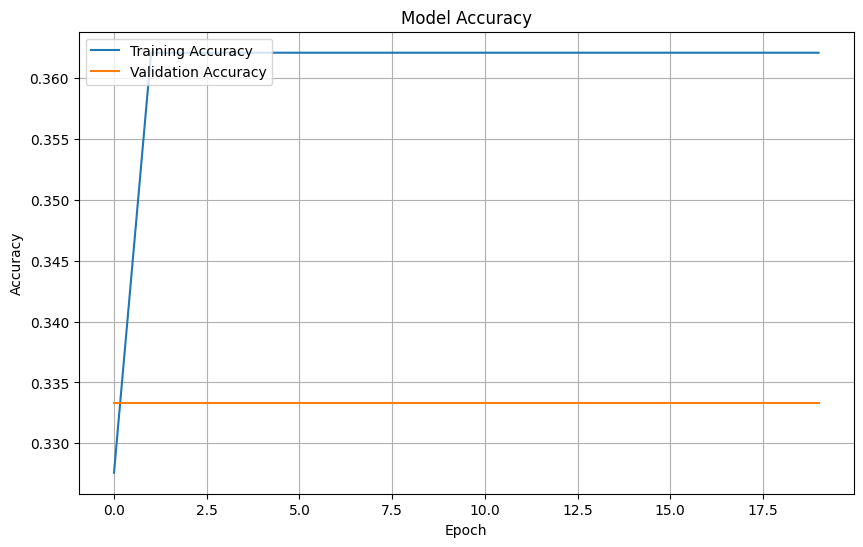

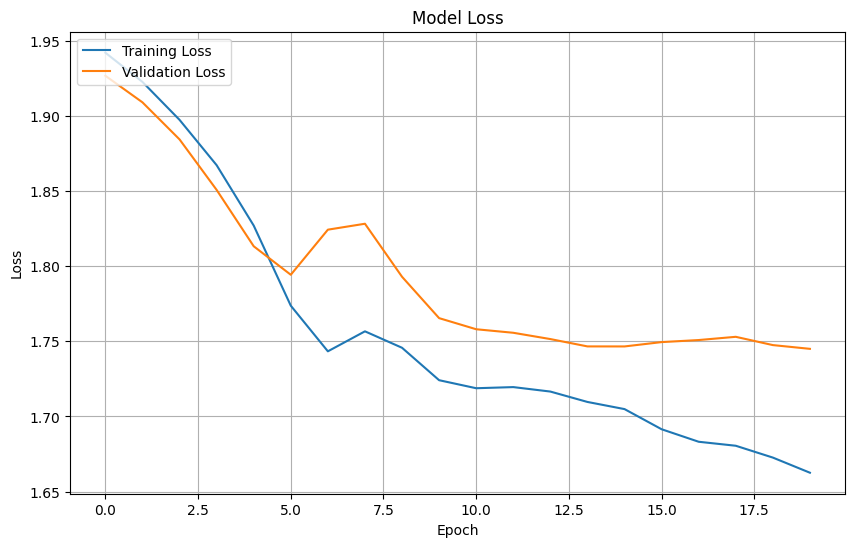

In [11]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy values
plt.figure(figsize=(10, 6))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(loc='upper left')
plt.grid(True)
plt.show()

# Plot training & validation loss values
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(loc='upper left')
plt.grid(True)
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 261ms/step


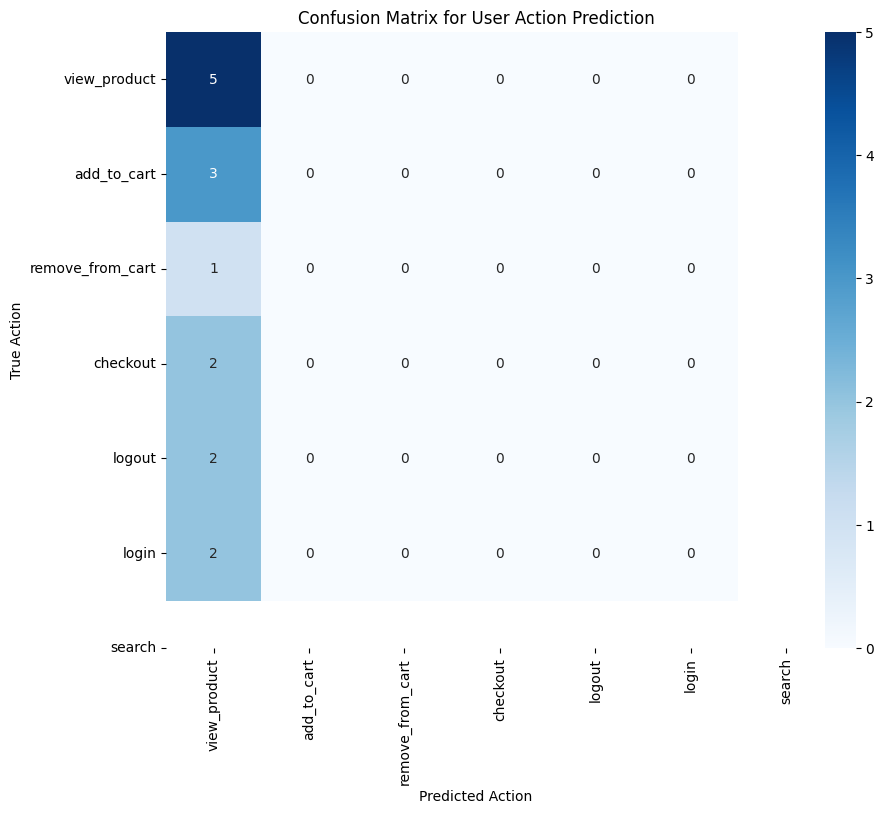

In [12]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Get predictions for the validation set
y_pred_probs = model.predict(X_val)
y_pred = np.argmax(y_pred_probs, axis=1)

# Compute the confusion matrix
cm = confusion_matrix(y_val, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=unique_actions, yticklabels=unique_actions)
plt.title('Confusion Matrix for User Action Prediction')
plt.xlabel('Predicted Action')
plt.ylabel('True Action')
plt.show()

## Model Deployment with FastAPI

To deploy the trained LSTM model as an API, we will use FastAPI, a modern, fast (high-performance) web framework for building APIs with Python 3.7+ based on standard Python type hints.

First, we need to save the trained model so it can be loaded by our FastAPI application.

In [16]:
# Install FastAPI and Uvicorn
!pip install fastapi uvicorn tensorflow

# Save the trained model
model_save_path = 'lstm_user_behavior_model.keras'
model.save(model_save_path)
print(f"Model saved to {model_save_path}")

Model saved to lstm_user_behavior_model.keras


Now, let's create the FastAPI application. This code will define an endpoint that accepts a sequence of action IDs, uses the loaded LSTM model to predict the next action, and returns the predicted action type.

In [17]:
import tensorflow as tf
from fastapi import FastAPI, HTTPException
from pydantic import BaseModel
import numpy as np

# Load the saved model
loaded_model = tf.keras.models.load_model(model_save_path)

# Create the FastAPI app
app = FastAPI(title="User Behavior Prediction API")

# Define the input data model
class SequenceInput(BaseModel):
    action_sequence: list[int] # Expects a list of action IDs

@app.post("/predict_next_action/")
async def predict_next_action(data: SequenceInput):
    # Ensure the input sequence length matches the model's expected input
    if len(data.action_sequence) != sequence_length:
        raise HTTPException(status_code=400, detail=f"Input sequence must be of length {sequence_length}")

    # Prepare the input for the model
    # The model expects a batch of sequences, so we add a batch dimension
    input_array = np.array(data.action_sequence).reshape(1, -1)

    # Make prediction
    predictions = loaded_model.predict(input_array)

    # Get the index of the most probable next action
    predicted_action_id = np.argmax(predictions, axis=1)[0]

    # Map the predicted action ID back to the original action type
    # Ensure unique_actions is accessible, assuming it's from the original factorization
    if 'unique_actions' not in globals():
        raise RuntimeError("unique_actions variable not found. Please ensure `pd.factorize` was run.")

    predicted_action_type = unique_actions[predicted_action_id]

    return {"predicted_next_action": predicted_action_type, "confidence": float(predictions[0][predicted_action_id])}

# To run this FastAPI app in Colab, you need a tunneling service like ngrok.
# Instructions for running with ngrok will be provided in the next cell.


To run the FastAPI application within Google Colab and expose it to the internet (or for local testing outside of Colab's environment), we'll use `uvicorn` and `ngrok`. `ngrok` creates a secure tunnel to your local machine, allowing public access to the FastAPI server running on a local port.

**Note**: You will need an `NGROK_AUTH_TOKEN`. If you don't have one, sign up at [ngrok.com](https://ngrok.com/), get your auth token, and add it to Colab's secrets manager (🔑 icon on the left panel) with the name `NGROK_AUTH_TOKEN`.

In [18]:
# Install pyngrok for Colab tunneling
!pip install pyngrok

from pyngrok import ngrok, conf
from google.colab import userdata
import uvicorn
import nest_asyncio

# Apply nest_asyncio to allow nested event loops (required for uvicorn in Colab)
nest_asyncio.apply()

# Get ngrok auth token from Colab secrets
NGROK_AUTH_TOKEN = userdata.get('NGROK_AUTH_TOKEN')

if NGROK_AUTH_TOKEN:
    conf.get_default().auth_token = NGROK_AUTH_TOKEN
    print("Ngrok Authtoken set.")
else:
    print("NGROK_AUTH_TOKEN not found in Colab secrets. Please add it to secrets manager.")

# Define the local port for FastAPI
local_port = 8000

# Start ngrok tunnel
public_url = ngrok.connect(local_port)
print(f"Public URL for your FastAPI app: {public_url}")

# Run FastAPI using uvicorn. Note: This will block the cell execution.
# You can access the API via the public_url provided by ngrok.
# To stop, interrupt this cell's execution.
print("Starting FastAPI application...")
uvicorn.run(app, host="0.0.0.0", port=local_port)

SecretNotFoundError: Secret NGROK_AUTH_TOKEN does not exist.

Once the above cell is running, your FastAPI application will be accessible via the `Public URL` printed by ngrok. You can send `POST` requests to this URL (e.g., `YOUR_PUBLIC_URL/predict_next_action/`) with a JSON body containing an `action_sequence` list. For example:

```json
{
  "action_sequence": [0, 1, 0, 2, 3]
}
```

The API will respond with the predicted next action type and its confidence.

In [19]:
# Install pyngrok for Colab tunneling
!pip install pyngrok

from pyngrok import ngrok, conf
from google.colab import userdata
import uvicorn
import nest_asyncio

# Apply nest_asyncio to allow nested event loops (required for uvicorn in Colab)
nest_asyncio.apply()

# Get ngrok auth token from Colab secrets
NGROK_AUTH_TOKEN = userdata.get('NGROK_AUTH_TOKEN')

if NGROK_AUTH_TOKEN:
    conf.get_default().auth_token = NGROK_AUTH_TOKEN
    print("Ngrok Authtoken set.")
else:
    print("NGROK_AUTH_TOKEN not found in Colab secrets. Please add it to secrets manager.")

# Define the local port for FastAPI
local_port = 8000

# Start ngrok tunnel
public_url = ngrok.connect(local_port)
print(f"Public URL for your FastAPI app: {public_url}")

# Run FastAPI using uvicorn. Note: This will block the cell execution.
# You can access the API via the public_url provided by ngrok.
# To stop, interrupt this cell's execution.
print("Starting FastAPI application...")
uvicorn.run(app, host="0.0.0.0", port=local_port)

SecretNotFoundError: Secret NGROK_AUTH_TOKEN does not exist.

### Test the Deployed FastAPI Endpoint

Once the FastAPI application is running (from the previous cell), you can test it by sending a POST request to the provided `public_url`. This example uses the `requests` library to send a sample `action_sequence` to your deployed model and prints the prediction.

In [21]:
import requests
import json

# IMPORTANT: Replace this with the actual public_url printed by ngrok
# when your FastAPI app is running in the previous cell.
# Example: public_url = NgrokTunnel(url='https://xxxxxxxxxxxx.ngrok-free.app', ...)
# You need to extract the URL part: 'https://xxxxxxxxxxxx.ngrok-free.app'

# You might need to manually copy the URL from the output of the previous cell
# For demonstration purposes, I'll use a placeholder.
# Replace 'YOUR_NGROK_PUBLIC_URL' with the actual URL.
# If you keep the previous cell running, you can try to get `public_url.public_url` from that cell scope,
# but it's safer to manually copy it after the ngrok tunnel is established.

# --- Placeholder for the ngrok public URL ---
# If the previous cell ran successfully and you have access to the `public_url` variable:
# try:
#     NGROK_URL = public_url.public_url
#     print(f"Using NGROK_URL from previous cell: {NGROK_URL}")
# except NameError:
#     print("public_url not found from previous cell. Please manually set NGROK_URL.")
#     NGROK_URL = "YOUR_NGROK_PUBLIC_URL" # <--- REPLACE THIS IF public_url is not accessible

# If you run this cell independently, copy the public URL string from the output of the FastAPI deployment cell.
NGROK_URL = "YOUR_NGROK_PUBLIC_URL" # <--- REPLACE THIS WITH THE ACTUAL URL

# Sample input sequence (must match sequence_length, which is 5)
# Convert numpy int64 to standard Python int for JSON serialization
sample_sequence = [int(x) for x in X_val[0]]
# Or a hardcoded example:
# sample_sequence = [0, 1, 0, 2, 3] # Example for 'view_product', 'add_to_cart', etc.


payload = {"action_sequence": sample_sequence}
headers = {"Content-Type": "application/json"}

predict_endpoint = f"{NGROK_URL}/predict_next_action/"

print(f"Sending request to: {predict_endpoint}")
print(f"Payload: {payload}")

try:
    response = requests.post(predict_endpoint, data=json.dumps(payload), headers=headers)
    response.raise_for_status() # Raise an HTTPError for bad responses (4xx or 5xx)

    result = response.json()
    print("\nPrediction Result:")
    print(json.dumps(result, indent=2))

except requests.exceptions.RequestException as e:
    print(f"Error connecting to the API: {e}")
    print("Please ensure the FastAPI server is running and the NGROK_URL is correct.")
except json.JSONDecodeError:
    print(f"Error decoding JSON response: {response.text}")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

Sending request to: YOUR_NGROK_PUBLIC_URL/predict_next_action/
Payload: {'action_sequence': [0, 1, 0, 2, 3]}
Error connecting to the API: Invalid URL 'YOUR_NGROK_PUBLIC_URL/predict_next_action/': No scheme supplied. Perhaps you meant https://YOUR_NGROK_PUBLIC_URL/predict_next_action/?
Please ensure the FastAPI server is running and the NGROK_URL is correct.


Remember to replace `"YOUR_NGROK_PUBLIC_URL"` in the code above with the actual URL provided by ngrok when the previous cell is successfully running the FastAPI application. The `sample_sequence` uses the first validation sequence for demonstration, but you can modify it to test other sequences.

## Academic Integrity Acknowledgement

This project utilized AI assistance for generating code snippets, explanations, and structuring parts of the notebook content. Specifically, large language models (LLMs) were used to:

*   Elaborate on project ideas and their detailed discussions.
*   Generate initial code for data preprocessing, model architecture, training, and deployment setup.
*   Provide explanations for various code sections and the underlying mathematical concepts (e.g., LSTM model).
*   Assist in debugging and refining code.

The core conceptualization and critical decision-making throughout the project remained under human oversight. AI tools served as intelligent assistants to accelerate development and provide comprehensive documentation.

### Project Idea 2: User Behavior Sequence Prediction for E-commerce

#### Discussion:

**Core Concept:**
This project aims to develop an LSTM (Long Short-Term Memory) model to predict the next action a user is likely to take on an e-commerce website. By analyzing sequences of past user interactions (e.g., viewing a product, adding to cart, searching, purchasing), the model will learn patterns and predict the subsequent behavior. This can be invaluable for personalized recommendations, dynamic content adjustments, and proactive engagement strategies.

**Potential Data Sources:**
1.  **User Interaction Logs:** This is the primary data source, capturing every click, view, search, add-to-cart, purchase, and other events with timestamps and user IDs. Each event should also include relevant item IDs and possibly other item attributes.
2.  **Product Catalog Data:** Information about products (categories, brands, prices, descriptions, images) can enrich the user's interaction data.
3.  **User Profile Data:** Demographic information, purchase history, and preference settings (if available and anonymized) can provide additional context.

**High-Level Steps for Building the Model:**
1.  **Data Collection and Preprocessing:** Extract user interaction logs, clean the data (handle missing values, anomalies), and anonymize user IDs. Create sequences of user actions, defining a 'session' or a fixed-length window for prediction.
2.  **Feature Engineering:** Convert categorical actions and product IDs into numerical representations (e.g., using embedding layers for actions and items). Consider features like time spent on a page, frequency of certain actions, or session duration.
3.  **Sequence Creation:** For each user, generate sequences of past actions and a corresponding target (the next action). For example, if a user's sequence is A -> B -> C, the model would learn to predict C given A -> B.
4.  **Model Architecture Design:** Implement an LSTM-based neural network. The input would be a sequence of embedded user actions, and the output would be a probability distribution over all possible next actions.
5.  **Model Training:** Train the LSTM model on the prepared sequences, using appropriate loss functions (e.g., categorical cross-entropy) and optimizers.
6.  **Model Evaluation:** Assess the model's performance using metrics like accuracy, precision, recall, F1-score, and perplexity (for sequence prediction). Evaluate how well it predicts the actual next action.

**Potential Deployment Aspects:**
1.  **Real-time Prediction API:** Deploy the trained model as a RESTful API service. When a user performs an action, the API receives the current user's session history and returns the predicted next action.
2.  **Integration with E-commerce Platform:** Integrate the prediction API with the e-commerce website's frontend or backend systems to power features like:
    *   **Next-best-action recommendations:** Suggesting the next product to view or add to cart.
    *   **Personalized notifications:** Triggering emails or push notifications based on predicted churn or purchase intent.
    *   **Dynamic UI adjustments:** Changing website layout or displaying relevant information based on predicted user needs.
3.  **Scalability:** Ensure the deployed solution can handle high traffic and process predictions with low latency.
4.  **Monitoring:** Continuously monitor model performance and data drift to ensure accuracy over time.

**Evaluation of Pros and Cons:**

**Pros:**
*   **Enhanced User Experience:** Provides highly personalized and relevant interactions, leading to increased user satisfaction.
*   **Increased Conversion Rates:** By predicting and facilitating desired user actions, the model can drive sales and conversions.
*   **Improved Engagement:** Proactive recommendations and content can keep users engaged on the platform.
*   **Valuable Business Insights:** Understanding user behavior sequences can reveal deeper insights into customer journeys and pain points.
*   **Applicable to Various Industries:** The concept of sequence prediction extends beyond e-commerce to areas like healthcare, education, and finance.

**Cons:**
*   **Data Intensive:** Requires a large volume of high-quality, sequential user interaction data, which might be complex to collect and store.
*   **Computational Cost:** Training and deploying LSTM models can be computationally expensive, especially with long sequences and large vocabularies of actions/items.
*   **Cold Start Problem:** New users or new products will have limited or no historical data, making predictions challenging initially.
*   **Interpretability:** LSTM models are often considered 'black boxes', making it difficult to understand *why* a particular prediction was made.
*   **Dynamic Nature of User Behavior:** User preferences and trends can change rapidly, requiring continuous model retraining and adaptation.
*   **Ethical Considerations:** Privacy concerns related to tracking and predicting user behavior, requiring careful anonymization and adherence to data protection regulations.